In [1]:
!pip -q install -U transformers datasets evaluate iterative-stratification openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.5 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import torch

from google.colab import drive

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss
)

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/toxic"

bangla = pd.read_excel(f"{BASE_PATH}/Bangla.xlsx")
banglish = pd.read_excel(f"{BASE_PATH}/Banglish.xlsx")

bangla["source"] = "bangla"
banglish["source"] = "banglish"

df = pd.concat([bangla, banglish], ignore_index=True)

print(df.shape)

(20468, 12)


In [5]:
TEXT_COL = "Text"

LABEL_COLS = [
    "Vulgar-based",
    "Religious-Hostility",
    "Troll-based",
    "Insult-based",
    "Loathe-based",
    "Threat-based",
    "Race-based",
    "Sexual-based",
    "Political-Chaos",
    "Non-Toxic"
]

In [6]:
df[TEXT_COL] = (
    df[TEXT_COL]
    .astype(str)
    .fillna("")
    .str.strip()
)

df = df[df[TEXT_COL].str.len()>0]

for c in LABEL_COLS:
    df[c] = (
        pd.to_numeric(df[c],errors="coerce")
        .fillna(0)
        .astype(int)
        .clip(0,1)
    )

df.reset_index(drop=True,inplace=True)

print(df.shape)

(20468, 12)


In [7]:
texts = df[TEXT_COL].tolist()

labels = df[LABEL_COLS].values.astype(np.float32)

print(texts[:2])
print(labels.shape)

['ইউসুফ সরকারকে এর চরম মূল্য দিতে হবে🤪', 'হাসিনা ইজ লাইক আওয়ার বাঙ্গালী বয়ফ্রেইন্ড, মানুষ আর দেশ এর পদ মাইরা বলবে “অপরাধ তা কি শুধুই আমার ?"😂']
(20468, 10)


In [8]:
kfold = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(kfold.split(texts,labels))

print("Number of folds:",len(folds))

Number of folds: 5


In [9]:
MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [10]:
class ToxicDataset(torch.utils.data.Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=192):

        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length
        )

        self.labels = labels.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [12]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probs = sigmoid(logits)

    preds = (probs >= 0.5).astype(int)

    return {

        "Micro_F1":
            f1_score(labels, preds,
                     average="micro",
                     zero_division=0),

        "Macro_F1":
            f1_score(labels, preds,
                     average="macro",
                     zero_division=0),

        "Micro_Precision":
            precision_score(labels, preds,
                            average="micro",
                            zero_division=0),

        "Macro_Precision":
            precision_score(labels, preds,
                            average="macro",
                            zero_division=0),

        "Micro_Recall":
            recall_score(labels, preds,
                         average="micro",
                         zero_division=0),

        "Macro_Recall":
            recall_score(labels, preds,
                         average="macro",
                         zero_division=0),

        "Subset_Accuracy":
            accuracy_score(labels, preds),

        "Hamming_Loss":
            hamming_loss(labels, preds)

    }

In [13]:
fold_results = []

In [14]:
import os
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/mBERT_5Fold"

os.makedirs(SAVE_DIR, exist_ok=True)

RESULT_FILE = os.path.join(SAVE_DIR, "fold_results.csv")

In [15]:
if os.path.exists(RESULT_FILE):

    fold_results = pd.read_csv(RESULT_FILE).to_dict("records")

    completed_folds = [x["Fold"] for x in fold_results]

    print("Already completed folds:", completed_folds)

else:

    fold_results = []

    completed_folds = []

In [18]:
import os
import gc
import pandas as pd
import torch

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR = "/content/drive/MyDrive/mBERT_5Fold"
os.makedirs(SAVE_DIR, exist_ok=True)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds):

    print("="*70)
    print(f"Training Fold {fold+1}/5")
    print("="*70)

    # Split data
    X_train = [texts[i] for i in train_idx]
    X_val   = [texts[i] for i in val_idx]

    y_train = labels[train_idx]
    y_val   = labels[val_idx]

    # Dataset
    train_ds = ToxicDataset(
        X_train,
        y_train,
        tokenizer
    )

    val_ds = ToxicDataset(
        X_val,
        y_val,
        tokenizer
    )

    # Fresh model for every fold
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_COLS),
        problem_type="multi_label_classification"
    )

    model.to(device)

    training_args = TrainingArguments(

        output_dir=os.path.join(SAVE_DIR, f"Fold_{fold+1}"),

        num_train_epochs=4,

        per_device_train_batch_size=16,

        per_device_eval_batch_size=16,

        learning_rate=2e-5,

        weight_decay=0.01,

        logging_steps=100,

        save_strategy="no",

        report_to="none",

        fp16=torch.cuda.is_available()

    )

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_ds,

        eval_dataset=val_ds,

        compute_metrics=compute_metrics

    )

    # Train
    trainer.train()

    # Evaluate
    metrics = trainer.evaluate()

    result = {

        "Fold": fold+1,

        "Micro F1": metrics.get("eval_Micro_F1", metrics.get("eval_micro_f1")),

        "Macro F1": metrics.get("eval_Macro_F1", metrics.get("eval_macro_f1")),

        "Micro Precision": metrics.get("eval_Micro_Precision", metrics.get("eval_micro_precision")),

        "Macro Precision": metrics.get("eval_Macro_Precision", metrics.get("eval_macro_precision")),

        "Micro Recall": metrics.get("eval_Micro_Recall", metrics.get("eval_micro_recall")),

        "Macro Recall": metrics.get("eval_Macro_Recall", metrics.get("eval_macro_recall")),

        "Subset Accuracy": metrics.get("eval_Subset_Accuracy", metrics.get("eval_subset_accuracy")),

        "Hamming Loss": metrics.get("eval_Hamming_Loss", metrics.get("eval_hamming_loss"))

    }

    fold_results.append(result);

    # Save model
    trainer.save_model(
        os.path.join(SAVE_DIR, f"Fold_{fold+1}")
    )

    tokenizer.save_pretrained(
        os.path.join(SAVE_DIR, f"Fold_{fold+1}")
    )

    print(result)

    del trainer
    del model

    gc.collect()
    torch.cuda.empty_cache()

# Save all results
results_df = pd.DataFrame(fold_results)

results_df.to_csv(
    os.path.join(SAVE_DIR, "mbert_5fold_results.csv"),
    index=False
)

print("\n========== Final Results ==========")
display(results_df)

print("\nAverage Performance")
display(results_df.mean(numeric_only=True))

Training Fold 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.414728
200,0.348424
300,0.305648
400,0.295801
500,0.291328
600,0.283379
700,0.261196
800,0.249643
900,0.249089
1000,0.257000


Training Loss,Validation Loss,Step,Micro F1,Macro F1,Micro Precision,Macro Precision,Micro Recall,Macro Recall,Subset Accuracy,Hamming Loss
0.147327,0.197380,4092,0.729683,0.643485,0.802554,0.735390,0.668944,0.586118,0.602190,0.075912


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'Fold': 5, 'Micro F1': 0.7310380533264302, 'Macro F1': 0.6476205130510542, 'Micro Precision': 0.800453514739229, 'Macro Precision': 0.7376662343651572, 'Micro Recall': 0.6727012863268222, 'Macro Recall': 0.5904346631673707, 'Subset Accuracy': 0.6062378167641326, 'Hamming Loss': 0.07595029239766082}

========== Final Results ==========


,Fold,Micro F1,Macro F1,Micro Precision,Macro Precision,Micro Recall,Macro Recall,Subset Accuracy,Hamming Loss
0,1,0.729683,0.643485,0.802554,0.735390,0.668944,0.586118,0.602190,0.075912
1,2,0.744524,0.661421,0.818736,0.761181,0.682648,0.599273,0.613742,0.072417
2,3,0.725909,0.635261,0.793929,0.715396,0.668625,0.584375,0.593910,0.077467
3,4,0.740460,0.659598,0.808807,0.751510,0.682764,0.600013,0.603829,0.073957
4,5,0.731038,0.647621,0.800454,0.737666,0.672701,0.590435,0.606238,0.075950



Average Performance


,0
Fold,3.000000
Micro F1,0.734323
Macro F1,0.649477
Micro Precision,0.804896
Macro Precision,0.740228
Micro Recall,0.675136
Macro Recall,0.592043
Subset Accuracy,0.603982
Hamming Loss,0.075141


XLM-R

In [19]:
MODEL_NAME = "xlm-roberta-base"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [20]:
SAVE_DIR = "/content/drive/MyDrive/XLMR_5Fold"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [21]:
import os
import gc
import pandas as pd
import torch

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds):

    print("="*70)
    print(f"Training Fold {fold+1}/5")
    print("="*70)

    X_train = [texts[i] for i in train_idx]
    X_val   = [texts[i] for i in val_idx]

    y_train = labels[train_idx]
    y_val   = labels[val_idx]

    train_ds = ToxicDataset(
        X_train,
        y_train,
        tokenizer
    )

    val_ds = ToxicDataset(
        X_val,
        y_val,
        tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_COLS),
        problem_type="multi_label_classification"
    )

    model.to(device)

    training_args = TrainingArguments(

        output_dir=os.path.join(
            SAVE_DIR,
            f"Fold_{fold+1}"
        ),

        num_train_epochs=4,

        learning_rate=2e-5,

        weight_decay=0.01,

        per_device_train_batch_size=16,

        per_device_eval_batch_size=16,

        logging_steps=100,

        save_strategy="no",

        report_to="none",

        fp16=torch.cuda.is_available()

    )

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_ds,

        eval_dataset=val_ds,

        compute_metrics=compute_metrics

    )

    trainer.train()

    metrics = trainer.evaluate()

    result = {

        "Fold": fold+1,

        "Micro F1": metrics.get("eval_Micro_F1", metrics.get("eval_micro_f1")),

        "Macro F1": metrics.get("eval_Macro_F1", metrics.get("eval_macro_f1")),

        "Micro Precision": metrics.get("eval_Micro_Precision", metrics.get("eval_micro_precision")),

        "Macro Precision": metrics.get("eval_Macro_Precision", metrics.get("eval_macro_precision")),

        "Micro Recall": metrics.get("eval_Micro_Recall", metrics.get("eval_micro_recall")),

        "Macro Recall": metrics.get("eval_Macro_Recall", metrics.get("eval_macro_recall")),

        "Subset Accuracy": metrics.get("eval_Subset_Accuracy", metrics.get("eval_subset_accuracy")),

        "Hamming Loss": metrics.get("eval_Hamming_Loss", metrics.get("eval_hamming_loss"))

    }

    fold_results.append(result)

    trainer.save_model(
        os.path.join(
            SAVE_DIR,
            f"Fold_{fold+1}"
        )
    )

    tokenizer.save_pretrained(
        os.path.join(
            SAVE_DIR,
            f"Fold_{fold+1}"
        )
    )

    print(result)

    del trainer
    del model

    gc.collect()
    torch.cuda.empty_cache()

results_df = pd.DataFrame(fold_results)

results_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "xlmr_5fold_results.csv"
    ),
    index=False
)

print("\nFinished.")
display(results_df)

Training Fold 1/5


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Step,Training Loss
100,0.433317
200,0.371438
300,0.324756
400,0.299883
500,0.296415
600,0.284562
700,0.284059
800,0.257409
900,0.267660
1000,0.250482


Training Loss,Validation Loss,Step,Micro F1,Macro F1,Micro Precision,Macro Precision,Micro Recall,Macro Recall,Subset Accuracy,Hamming Loss
0.169182,0.184050,4092,0.748298,0.672797,0.806049,0.752889,0.698269,0.616138,0.605750,0.072076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'Fold': 5, 'Micro F1': 0.7482981620149761, 'Macro F1': 0.672796554956867, 'Micro Precision': 0.8060494958753437, 'Macro Precision': 0.7528893666899157, 'Micro Recall': 0.6982690169922185, 'Macro Recall': 0.6161381836672329, 'Subset Accuracy': 0.6057504873294347, 'Hamming Loss': 0.07207602339181286}

Finished.


,Fold,Micro F1,Macro F1,Micro Precision,Macro Precision,Micro Recall,Macro Recall,Subset Accuracy,Hamming Loss
0,1,0.750682,0.672464,0.809594,0.753837,0.699762,0.617960,0.613382,0.071192
1,2,0.753608,0.675627,0.815527,0.760164,0.700429,0.618742,0.616687,0.070798
2,3,0.727257,0.634746,0.790494,0.727140,0.673388,0.574704,0.596833,0.077491
3,4,0.736507,0.646890,0.802284,0.734795,0.680699,0.585839,0.596465,0.075258
4,5,0.748298,0.672797,0.806049,0.752889,0.698269,0.616138,0.605750,0.072076


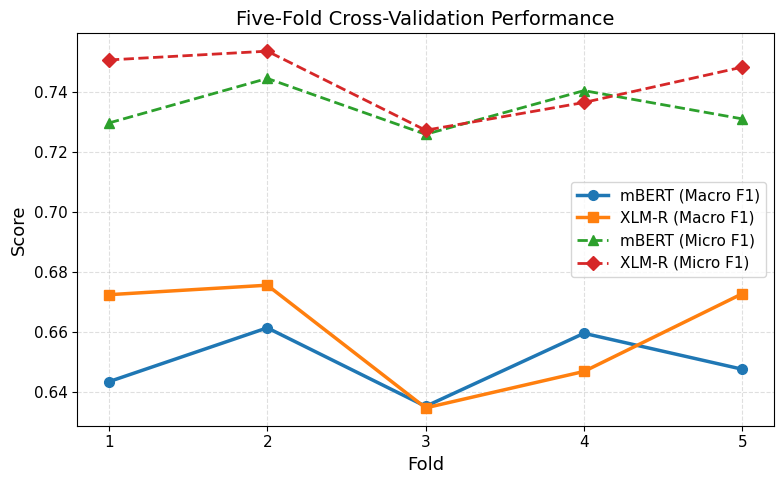

In [22]:
import matplotlib.pyplot as plt

# ==========================
# Fold-wise Results
# ==========================

folds = [1, 2, 3, 4, 5]

mbert_macro = [0.643485, 0.661421, 0.635261, 0.659598, 0.647621]
xlmr_macro  = [0.672464, 0.675627, 0.634746, 0.646890, 0.672797]

mbert_micro = [0.729683, 0.744524, 0.725909, 0.740460, 0.731038]
xlmr_micro  = [0.750682, 0.753608, 0.727257, 0.736507, 0.748298]

# ==========================
# Publication Style
# ==========================

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ==========================
# Plot
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    folds,
    mbert_macro,
    marker='o',
    linewidth=2.5,
    markersize=7,
    label='mBERT (Macro F1)'
)

plt.plot(
    folds,
    xlmr_macro,
    marker='s',
    linewidth=2.5,
    markersize=7,
    label='XLM-R (Macro F1)'
)

plt.plot(
    folds,
    mbert_micro,
    marker='^',
    linewidth=2,
    linestyle='--',
    markersize=7,
    label='mBERT (Micro F1)'
)

plt.plot(
    folds,
    xlmr_micro,
    marker='D',
    linewidth=2,
    linestyle='--',
    markersize=7,
    label='XLM-R (Micro F1)'
)

plt.xticks(folds)

plt.xlabel("Fold")
plt.ylabel("Score")

plt.title("Five-Fold Cross-Validation Performance")

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "5fold_comparison.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "5fold_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()